DSCI 552 Homework 7
===================

- Name: Umaeshwer Shankar
- GitHub Username: umaeshwer
- USD ID: 7601-5514-88

# Import Libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, zero_one_loss, accuracy_score, hamming_loss
from imblearn.over_sampling import SMOTE

# 1. Multi-class and Multi-Label Classification Using Support Vector Machines

(a) Download the Anuran Calls (MFCCs) Data Set from: https://archive.ics.uci.edu/ml/datasets/Anuran+Calls+%28MFCCs%29. Choose 70% of the data
randomly as the training set.

In [58]:
df = pd.read_csv('../data/Anuran Calls (MFCCs)/Frogs_MFCCs.csv', header=0)
                 
df.head()

,MFCCs_ 1,MFCCs_ 2,MFCCs_ 3,MFCCs_ 4,MFCCs_ 5,MFCCs_ 6,MFCCs_ 7,MFCCs_ 8,MFCCs_ 9,MFCCs_10,...,MFCCs_17,MFCCs_18,MFCCs_19,MFCCs_20,MFCCs_21,MFCCs_22,Family,Genus,Species,RecordID
0,1.0,0.152936,-0.105586,0.200722,0.317201,0.260764,0.100945,-0.150063,-0.171128,0.124676,...,-0.108351,-0.077623,-0.009568,0.057684,0.118680,0.014038,Leptodactylidae,Adenomera,AdenomeraAndre,1
1,1.0,0.171534,-0.098975,0.268425,0.338672,0.268353,0.060835,-0.222475,-0.207693,0.170883,...,-0.090974,-0.056510,-0.035303,0.020140,0.082263,0.029056,Leptodactylidae,Adenomera,AdenomeraAndre,1
2,1.0,0.152317,-0.082973,0.287128,0.276014,0.189867,0.008714,-0.242234,-0.219153,0.232538,...,-0.050691,-0.023590,-0.066722,-0.025083,0.099108,0.077162,Leptodactylidae,Adenomera,AdenomeraAndre,1
3,1.0,0.224392,0.118985,0.329432,0.372088,0.361005,0.015501,-0.194347,-0.098181,0.270375,...,-0.136009,-0.177037,-0.130498,-0.054766,-0.018691,0.023954,Leptodactylidae,Adenomera,AdenomeraAndre,1
4,1.0,0.087817,-0.068345,0.306967,0.330923,0.249144,0.006884,-0.265423,-0.172700,0.266434,...,-0.048885,-0.053074,-0.088550,-0.031346,0.108610,0.079244,Leptodactylidae,Adenomera,AdenomeraAndre,1


In [59]:
X = df.drop(['Family', 'Genus', 'Species', 'RecordID'], axis=1)
y_family = df['Family']
y_genus = df['Genus']
y_species = df['Species']

X_train, X_test, y_family_train, y_family_test, y_genus_train, y_genus_test, y_species_train, y_species_test = train_test_split(
    X, y_family, y_genus, y_species, test_size=0.3, random_state=42
)

(b) Each instance has three labels: Families, Genus, and Species. Each of the labels has multiple classes. We wish to solve a multi-class and multi-label problem. One of the most important approaches to multi-label classification is to train a classifier for each label (binary relevance). We first try this approach:

i. Research exact match and hamming score/ loss methods for evaluating multi-label classification and use them in evaluating the classifiers in this problem.

=============

## Multi-Label Classification Evaluation Metrics

1. Exact Match

    Fraction of samples where all class labels match exactly with the ground truth. Rigid metric.

2. Hamming Loss and Hamming Score

    Fraction of labels that are incorrectly predicted across all instances and labels. Hamming Score = 1 - Hamming Loss.

=============

ii. Train a SVM for each of the labels, using Gaussian kernels and one versus all classifiers. Determine the weight of the SVM penalty and the width of the Gaussian Kernel using 10 fold cross validation. You are welcome to try to solve the problem with both standardized and raw attributes and report the results.

===========

Notes:

1. How to choose parameter ranges for SVMs? One can use wide ranges for the parameters and a fine grid (e.g. 1000 points) for cross validation; however,this method may be computationally expensive. An alternative way is to train the SVM with very large and very small parameters on the whole training data and find very large and very small parameters for which the training accuracy is not below a threshold (e.g.,
70%). Then one can select a fixed number of parameters (e.g., 20) between those points for cross validation. For the penalty parameter, usually one has to consider increments in log(λ). For example, if one found that the accuracy of a support vector machine will not be below 70% for λ= 10−3 and λ= 106, one has to choose log(λ) ∈{−3,−2,...,4,5,6}. For the Gaussian Kernel parameter, one usually chooses linear increments, e.g. σ ∈{.1,.2,...,2}. When both σ and λ are to be chosen using cross-validation, combinations of very small and very large λ’s and σ’s that keep the accuracy above a threshold (e.g.70%) can be used to determine the ranges for σ and λ. Please note that these are very rough rules of thumb, not general procedures.

2. It seems that the data are already normalized.

==============

In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


C_range = np.logspace(-3, 6, 10) 
gamma_range = np.linspace(0.1, 2, 10)

results = {}
labels = {'Family': (y_family_train, y_family_test), 
          'Genus': (y_genus_train, y_genus_test), 
          'Species': (y_species_train, y_species_test)}

for label_name, (y_train, y_test) in labels.items():
    param_grid = {'C': C_range, 'gamma': gamma_range}
    svm = SVC(kernel='rbf')
    grid_search = GridSearchCV(svm, param_grid, cv=10, n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)
    
    y_train_pred = grid_search.best_estimator_.predict(X_train_scaled)
    y_test_pred = grid_search.best_estimator_.predict(X_test_scaled)
    
    train_exact_match = 1 - zero_one_loss(y_train, y_train_pred)
    test_exact_match = 1 - zero_one_loss(y_test, y_test_pred)

    train_hamming_score = accuracy_score(y_train, y_train_pred)
    test_hamming_score = accuracy_score(y_test, y_test_pred)
    
    train_hamming_loss = hamming_loss(y_train, y_train_pred)
    test_hamming_loss = hamming_loss(y_test, y_test_pred)
    
    results[label_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'model': grid_search.best_estimator_,
        'train_exact_match': train_exact_match,
        'test_exact_match': test_exact_match,
        'train_hamming_loss': train_hamming_loss,
        'test_hamming_loss': test_hamming_loss
    }
    
    print(f"\n{label_name} (Gaussian SVM):")
    print(f"Best parameters: {results[label_name]['best_params']}")
    print(f"Cross-validation score: {results[label_name]['best_score']:.4f}")
    print(f"\nTrain Metrics:")
    print(f"  Exact Match: {results[label_name]['train_exact_match']:.4f}")
    print(f"  Hamming Loss: {results[label_name]['train_hamming_loss']:.4f}")
    print(f"\nTest Metrics:")
    print(f"  Exact Match: {results[label_name]['test_exact_match']:.4f}")
    print(f"  Hamming Loss: {results[label_name]['test_hamming_loss']:.4f}")


Family (Gaussian SVM):
Best parameters: {'C': np.float64(10.0), 'gamma': np.float64(0.1)}
Cross-validation score: 0.9911

Train Metrics:
  Exact Match: 1.0000
  Hamming Loss: 0.0000

Test Metrics:
  Exact Match: 0.9926
  Hamming Loss: 0.0074

Genus (Gaussian SVM):
Best parameters: {'C': np.float64(10.0), 'gamma': np.float64(0.1)}
Cross-validation score: 0.9877

Train Metrics:
  Exact Match: 1.0000
  Hamming Loss: 0.0000

Test Metrics:
  Exact Match: 0.9880
  Hamming Loss: 0.0120

Species (Gaussian SVM):
Best parameters: {'C': np.float64(10.0), 'gamma': np.float64(0.1)}
Cross-validation score: 0.9847

Train Metrics:
  Exact Match: 1.0000
  Hamming Loss: 0.0000

Test Metrics:
  Exact Match: 0.9843
  Hamming Loss: 0.0157


iii. Repeat 1(b)ii with L1-penalized SVMs. Remember to standardize the attributes. Determine the weight of the SVM penalty using 10 fold cross validation.

===============

Notes:

1. The convention is to use L1 penalty with linear kernel.

2. It seems that the data are already normalized.

===============

In [61]:
results_l1 = {}

for label_name, (y_train, y_test) in labels.items():
    param_grid = {'C': C_range}
    svm = LinearSVC(penalty='l1', dual=False, multi_class='ovr', max_iter=10000)
    grid_search = GridSearchCV(svm, param_grid, cv=10, n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)
    
    y_train_pred = grid_search.best_estimator_.predict(X_train_scaled)
    y_test_pred = grid_search.best_estimator_.predict(X_test_scaled)
    
    train_exact_match = 1 - zero_one_loss(y_train, y_train_pred)
    test_exact_match = 1 - zero_one_loss(y_test, y_test_pred)
    
    train_hamming_loss = hamming_loss(y_train, y_train_pred)
    test_hamming_loss = hamming_loss(y_test, y_test_pred)
    
    results_l1[label_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'model': grid_search.best_estimator_,
        'train_exact_match': train_exact_match,
        'test_exact_match': test_exact_match,
        'train_hamming_loss': train_hamming_loss,
        'test_hamming_loss': test_hamming_loss
    }
    
    print(f"\n{label_name} (L1-penalized SVM):")
    print(f"Best parameters: {results_l1[label_name]['best_params']}")
    print(f"Cross-validation score: {results_l1[label_name]['best_score']:.4f}")
    print(f"\nTrain Metrics:")
    print(f"  Exact Match: {results_l1[label_name]['train_exact_match']:.4f}")
    print(f"  Hamming Loss: {results_l1[label_name]['train_hamming_loss']:.4f}")
    print(f"\nTest Metrics:")
    print(f"  Exact Match: {results_l1[label_name]['test_exact_match']:.4f}")
    print(f"  Hamming Loss: {results_l1[label_name]['test_hamming_loss']:.4f}")


Family (L1-penalized SVM):
Best parameters: {'C': np.float64(1.0)}
Cross-validation score: 0.9406

Train Metrics:
  Exact Match: 0.9426
  Hamming Loss: 0.0574

Test Metrics:
  Exact Match: 0.9287
  Hamming Loss: 0.0713


/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  


Genus (L1-penalized SVM):
Best parameters: {'C': np.float64(10.0)}
Cross-validation score: 0.9527

Train Metrics:
  Exact Match: 0.9563
  Hamming Loss: 0.0437

Test Metrics:
  Exact Match: 0.9416
  Hamming Loss: 0.0584


/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  


Species (L1-penalized SVM):
Best parameters: {'C': np.float64(10.0)}
Cross-validation score: 0.9603

Train Metrics:
  Exact Match: 0.9647
  Hamming Loss: 0.0353

Test Metrics:
  Exact Match: 0.9592
  Hamming Loss: 0.0408


iv. Repeat 1(b)iii by using SMOTE or any other method you know to remedy class imbalance. Report your conclusions about the classifiers you trained.

In [62]:
results_smote = {}

for label_name, (y_train, y_test) in labels.items():
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
    
    param_grid = {'C': C_range}
    svm = LinearSVC(penalty='l1', dual=False, multi_class='ovr', max_iter=10000)
    grid_search = GridSearchCV(svm, param_grid, cv=10, n_jobs=-1)
    grid_search.fit(X_train_smote, y_train_smote)
    
    y_train_pred = grid_search.best_estimator_.predict(X_train_smote)
    y_test_pred = grid_search.best_estimator_.predict(X_test_scaled)
    
    train_exact_match = 1 - zero_one_loss(y_train_smote, y_train_pred)
    test_exact_match = 1 - zero_one_loss(y_test, y_test_pred)
    
    train_hamming_loss = hamming_loss(y_train_smote, y_train_pred)
    test_hamming_loss = hamming_loss(y_test, y_test_pred)
    
    results_smote[label_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'model': grid_search.best_estimator_,
        'train_exact_match': train_exact_match,
        'test_exact_match': test_exact_match,
        'train_hamming_loss': train_hamming_loss,
        'test_hamming_loss': test_hamming_loss
    }
    
    print(f"\n{label_name} (L1-SVM with SMOTE):")
    print(f"Best parameters: {results_smote[label_name]['best_params']}")
    print(f"Cross-validation score: {results_smote[label_name]['best_score']:.4f}")
    print(f"\nTrain Metrics:")
    print(f"  Exact Match: {results_smote[label_name]['train_exact_match']:.4f}")
    print(f"  Hamming Loss: {results_smote[label_name]['train_hamming_loss']:.4f}")
    print(f"\nTest Metrics:")
    print(f"  Exact Match: {results_smote[label_name]['test_exact_match']:.4f}")
    print(f"  Hamming Loss: {results_smote[label_name]['test_hamming_loss']:.4f}")


Family (L1-SVM with SMOTE):
Best parameters: {'C': np.float64(100.0)}
Cross-validation score: 0.9512

Train Metrics:
  Exact Match: 0.9526
  Hamming Loss: 0.0474

Test Metrics:
  Exact Match: 0.9092
  Hamming Loss: 0.0908

Genus (L1-SVM with SMOTE):
Best parameters: {'C': np.float64(10.0)}
Cross-validation score: 0.9603

Train Metrics:
  Exact Match: 0.9617
  Hamming Loss: 0.0383

Test Metrics:
  Exact Match: 0.9018
  Hamming Loss: 0.0982

Species (L1-SVM with SMOTE):
Best parameters: {'C': np.float64(10000.0)}
Cross-validation score: 0.9635

Train Metrics:
  Exact Match: 0.9641
  Hamming Loss: 0.0359

Test Metrics:
  Exact Match: 0.9579
  Hamming Loss: 0.0421


# 2. K-Means Clustering on a Multi-Class and Multi-Label Data Set

Monte-Carlo Simulation: Perform the following procedures 50 times, and report the average and standard deviation of the 50 Hamming Distances that you calculate.

(a) Use k-means clustering on the whole Anuran Calls (MFCCs) Data Set (do not split the data into train and test, as we are not performing supervised learning in this exercise). Choose k ∈{1, 2, . . . , 50}automatically based on one of the methods provided in the slides (CH or Gap Statistics or scree plots or Silhouettes) or any other method you know.

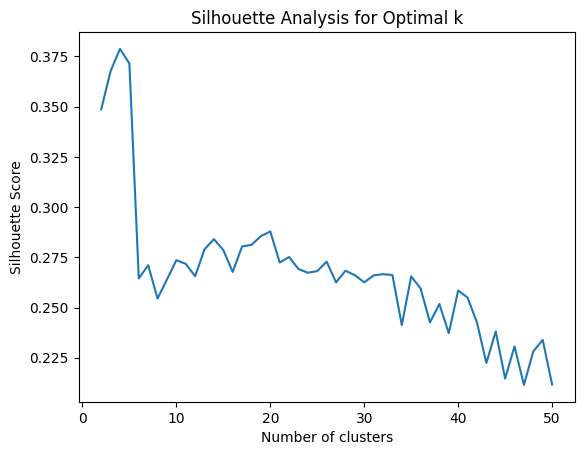

Optimal k: 4


In [63]:
X = df.drop(['Family', 'Genus', 'Species', 'RecordID'], axis=1)

silhouette_scores = []
k_range = range(2, 51)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X)
    score = silhouette_score(X, clusters)
    silhouette_scores.append(score)

plt.plot(k_range, silhouette_scores)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal k')
plt.show()

k_opt = k_range[np.argmax(silhouette_scores)]
print(f"Optimal k: {k_opt}")

kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

(b) In each cluster, determine which family is the majority by reading the true labels. Repeat for genus and species.

In [64]:
for cluster in df['Cluster'].unique():
    cluster_data = df[df['Cluster'] == cluster]
    
    majority_family = cluster_data['Family'].value_counts().idxmax()
    majority_genus = cluster_data['Genus'].value_counts().idxmax()
    majority_species = cluster_data['Species'].value_counts().idxmax()
    
    print(f"Cluster {cluster}: Majority Family - {majority_family}, Genus - {majority_genus}, Species - {majority_species}")

Cluster 2: Majority Family - Dendrobatidae, Genus - Ameerega, Species - Ameeregatrivittata
Cluster 3: Majority Family - Hylidae, Genus - Hypsiboas, Species - HypsiboasCordobae
Cluster 1: Majority Family - Hylidae, Genus - Hypsiboas, Species - HypsiboasCinerascens
Cluster 0: Majority Family - Leptodactylidae, Genus - Adenomera, Species - AdenomeraHylaedactylus


(c) Now for each cluster you have a majority label triplet (family, genus, species). Calculate the average Hamming distance, Hamming score, and Hamming loss between the true labels and the labels assigned by clusters.

============

Notes:

1. Research what these scores are. For example, see the paper A Literature Survey on Algorithms for Multi-label Learning, by Mohammad Sorower.

============

In [65]:
majority_labels = {}
for cluster in df['Cluster'].unique():
    cluster_data = df[df['Cluster'] == cluster]
    majority_family = cluster_data['Family'].value_counts().idxmax()
    majority_genus = cluster_data['Genus'].value_counts().idxmax()
    majority_species = cluster_data['Species'].value_counts().idxmax()
    majority_labels[cluster] = (majority_family, majority_genus, majority_species)

hamming_distances = []
total_mismatches = 0
n = len(df)
m = 3 

for idx, row in df.iterrows():
    cluster = row['Cluster']
    pred_family, pred_genus, pred_species = majority_labels[cluster]
    true_family, true_genus, true_species = row['Family'], row['Genus'], row['Species']
    
    mismatches = 0
    if pred_family != true_family:
        mismatches += 1
    if pred_genus != true_genus:
        mismatches += 1
    if pred_species != true_species:
        mismatches += 1
    
    hamming_distances.append(mismatches)
    total_mismatches += mismatches

avg_hamming_distance = np.mean(hamming_distances)
hamming_loss = total_mismatches / (n * m)

print(f"Average Hamming Distance: {avg_hamming_distance:.4f}")
print(f"Hamming Loss: {hamming_loss:.4f}")

Average Hamming Distance: 0.6673
Hamming Loss: 0.2224


# Conceptual Questions

## ISLR 12.6.2

Suppose that we have four observations, for which we compute a dissimilarity matrix, given by

$$
\begin{pmatrix}
- & 0.3 & 0.4 & 0.7 \\
0.3 & - & 0.5 & 0.8 \\
0.4 & 0.5 & - & 0.45 \\
0.7 & 0.8 & 0.45 & -
\end{pmatrix}
$$

For instance, the dissimilarity between the first and second observations is 0.3, and the dissimilarity between the second and fourth
observations is 0.8.


(a) On the basis of this dissimilarity matrix, sketch the dendrogram that results from hierarchically clustering these four observations using complete linkage. Be sure to indicate on the plot the height at which each fusion occurs, as well as the observations corresponding to each leaf in the dendrogram.

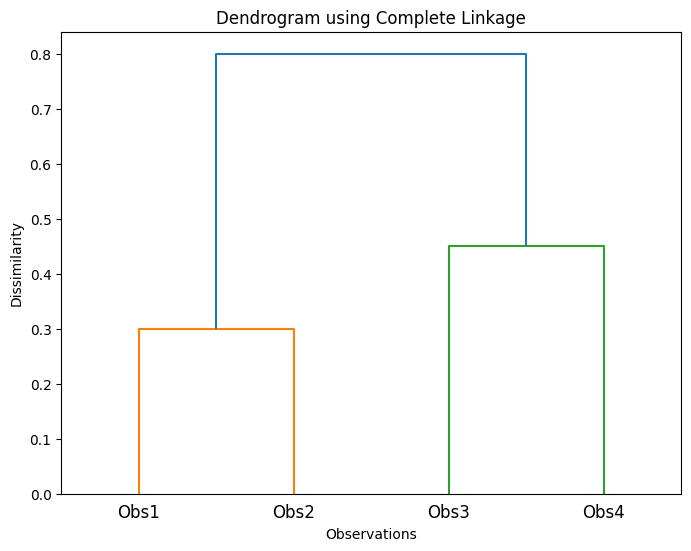

In [66]:
distances = np.array([0.3, 0.4, 0.7, 0.5, 0.8, 0.45])

Z = linkage(distances, method='complete')

plt.figure(figsize=(8, 6))
dendrogram(Z, labels=['Obs1', 'Obs2', 'Obs3', 'Obs4'])
plt.title('Dendrogram using Complete Linkage')
plt.xlabel('Observations')
plt.ylabel('Dissimilarity')
plt.show()

(b) Repeat (a), this time using single linkage clustering.

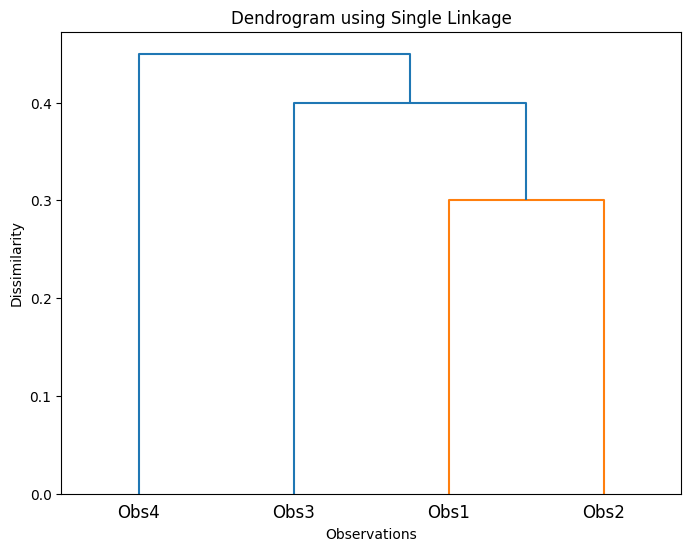

In [67]:
Z = linkage(distances, method='single')

plt.figure(figsize=(8, 6))
dendrogram(Z, labels=['Obs1', 'Obs2', 'Obs3', 'Obs4'])
plt.title('Dendrogram using Single Linkage')
plt.xlabel('Observations')
plt.ylabel('Dissimilarity')
plt.show()

(c) Suppose that we cut the dendrogram obtained in (a) such that two clusters result. Which observations are in each cluster?

=======

Answer:

If we cut the dendrogram such that two clusters result, we will have the following result

Cluster A: Observations 1 and 2


Cluster B: Observations 3 and 4

=======

(d) Suppose that we cut the dendrogram obtained in (b) such that two clusters result. Which observations are in each cluster?

=======

Answer:

If we cut the dendrogram such that two clusters result, we will have the following result

Cluster A: Observations 1, 2 and 3


Cluster B: Observation 4


=======

(e) It is mentioned in the chapter that at each fusion in the dendrogram, the position of the two clusters being fused can be
swapped without changing the meaning of the dendrogram. Draw a dendrogram that is equivalent to the dendrogram in (a), for which two or more of the leaves are repositioned, but for which the meaning of the dendrogram is the same.

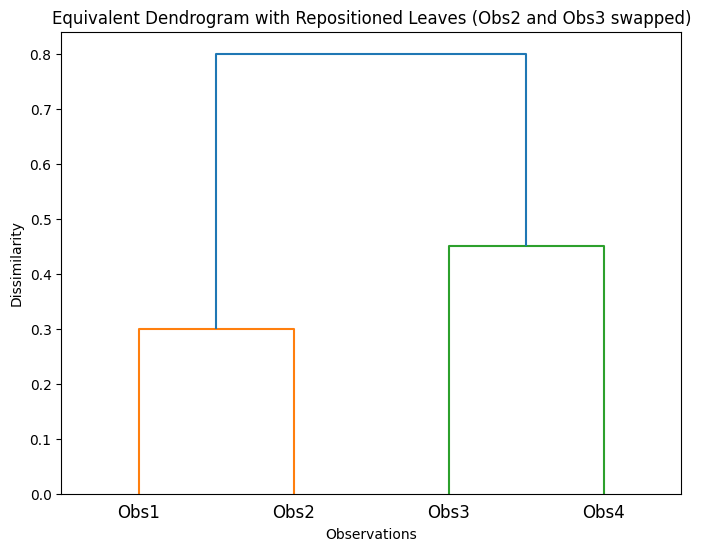

In [68]:
distances_permutation = np.array([0.4, 0.3, 0.7, 0.5, 0.45, 0.8])

Z_perm = linkage(distances_permutation, method='complete')

plt.figure(figsize=(8, 6))
dendrogram(Z_perm, labels=['Obs1', 'Obs3', 'Obs2', 'Obs4'])
plt.title('Equivalent Dendrogram with Repositioned Leaves (Obs2 and Obs3 swapped)')
plt.xlabel('Observations')
plt.ylabel('Dissimilarity')
plt.show()